In [1]:
#! pip install python-shogi 

In [2]:
import sys
print (sys.path)

['/mnt/c/Users/hmats/workspace/DeepLearningShogi/notebook', '/home/hmatsuya/anaconda3/lib/python38.zip', '/home/hmatsuya/anaconda3/lib/python3.8', '/home/hmatsuya/anaconda3/lib/python3.8/lib-dynload', '', '/home/hmatsuya/.local/lib/python3.8/site-packages', '/home/hmatsuya/anaconda3/lib/python3.8/site-packages', '/mnt/c/Users/hmats/workspace/Ayane', '/mnt/c/Users/hmats/workspace/Ayane/source', '/home/hmatsuya/anaconda3/lib/python3.8/site-packages/IPython/extensions', '/home/hmatsuya/.ipython']


In [3]:
import shogi
from shogi import CSA

In [4]:
from bs4 import BeautifulSoup

In [5]:
import requests

In [6]:
import io

In [7]:
from datetime import date, timedelta, datetime

In [8]:
import time

In [9]:
import re

In [10]:
import os

In [11]:
import pickle

In [12]:
import pandas

In [13]:
import cshogi

## Set suffix

In [14]:
suffix = "20210425"

### Download competition page (https://golan.sakura.ne.jp/denryusen/dr1_test4a/dr1_live.php)

In [23]:
def get_denryu_links(live_url):
    page = requests.get(live_url)
    soup = BeautifulSoup(page.content, 'html.parser')
    links = soup.find_all('a')
    urls = []
    for link in links:
        href = link.attrs['href']
        if 'denryusen_single' in href and 'suisho' in href:
            match_id = href.split('#')[-1]

            # url
            csa_address = "https://golan.sakura.ne.jp/denryusen/dr1_test4a/kifufiles/" + match_id + '.csa'
            urls.append(csa_address)
        elif 'dr1test1' in href and 'suisho' in href:
            match_id = href.split('/')[-1].split('.')[-2]

            # url
            csa_address = "https://golan.sakura.ne.jp/denryusen/dr1_test4a/kifufiles/" + match_id + '.csa'
            urls.append(csa_address)
    print(len(urls))
    return urls

denryu_urls = get_denryu_links("https://golan.sakura.ne.jp/denryusen/dr1_test1/dr1_live.php")
denryu_urls += get_denryu_links("https://golan.sakura.ne.jp/denryusen/dr1_test2/dr1_live.php")
denryu_urls += get_denryu_links("https://golan.sakura.ne.jp/denryusen/dr1_test3/dr1_live.php")
denryu_urls = get_denryu_links("https://golan.sakura.ne.jp/denryusen/dr1_test4a/dr1_live.php")
len(denryu_urls)

19
30
57
90


90

### Iterate over matches

#### Download CSA record if interested

#### Convert CSA to SFEN

#### Extract meta data from the record

#### Merge SFEN and meta data

#### Accumulate SFEN

In [24]:
def get_eval(csa):
    values = []
    for m in re.finditer("'\*\*\s+(-?\d+)", csa, re.MULTILINE):
        values.append(int(m.group(1)))
        
#     return [values[0::2], values[1::2]]
    return values

In [25]:
def get_sfen_from_csa(csa):
    # Convert CSA to SFEN
    try:
        sfen = CSA.Parser.parse_str(csa)[0]
        sfen['csa'] = csa
        sfen['url'] = url
        sfen['record'] = 'sfen ' + sfen['sfen'] + ' moves ' + ' '.join(sfen['moves'])
        sfen['values'] = get_eval(csa)
        sfen['toryo'] = (re.search("%TORYO|%KACHI", csa) != None)
#         print(sfen['values'])
#         print(len(sfen['moves']), len(sfen['values']), sfen['toryo'])
    
        return sfen
    except Exception as e:
#         print(csa)
        print("Error parsing record:" + url)
        print(type(e), e)
        return None

In [26]:
# def get_sfen(url):
#     # Download
#     csa_page = requests.get(url)
#     csa = csa_page.content.decode()

#     # Convert CSA to SFEN
#     try:
#         sfen = CSA.Parser.parse_str(csa)[0]
#         sfen['record'] = 'sfen ' + sfen['sfen'] + ' moves ' + ' '.join(sfen['moves'])
#         return sfen
#     except:
#         print(csa)
#         return None
def get_sfen(url):
    # Download
    csa_page = requests.get(url)
    csa = csa_page.content.decode()

    # Convert CSA to SFEN
    try:
        sfen = CSA.Parser.parse_str(csa)[0]
        sfen['csa'] = csa
        sfen['url'] = url
        sfen['record'] = 'sfen ' + sfen['sfen'] + ' moves ' + ' '.join(sfen['moves'])
        sfen['values'] = get_eval(csa)
        sfen['toryo'] = (re.search("%TORYO|%KACHI", csa) != None)
#         print(sfen['values'])
#         print(len(sfen['moves']), len(sfen['values']), sfen['toryo'])
    
        return sfen
    except Exception as e:
#         print(csa)
        print("Error parsing record:" + url)
        print(type(e), e)
        return None

In [27]:
# with open(f'dr_black{suffix}.sfen', 'w') as fb, open(f'dr_white{suffix}.sfen', 'w') as fw:
#     for csa_url in denryu_urls:
#         sfen = get_sfen(csa_url)
#         if sfen == None:
#             continue

#         # Write out
#         print(sfen['names'])
#         if 'suisho' == sfen['names'][0] and sfen['win'] == 'b':
#             fb.write(sfen['record'] + '\n')
#         if 'suisho' == sfen['names'][1] and sfen['win'] == 'w':
#             fw.write(sfen['record'] + '\n')


### Download Floodgate records

#### Download ratings

In [16]:
rating_page = requests.get('http://wdoor.c.u-tokyo.ac.jp/shogi/logs/LATEST/players-floodgate.html')

In [17]:
soup = BeautifulSoup(rating_page.content, 'html.parser')

In [18]:
names = soup.select('td.name a')
ratings =  soup.select('td.rate span')
print(len(names), len(ratings))
assert(len(names) == len(ratings))

engine_names = []

for i in range(len(names)):
    name = names[i].contents[0]
    try:
        rating = int(ratings[i].contents[0])
    except:
        rating = -9999
    if rating >= 4200:
        engine_names.append(name)
        print(name, rating)
        
# with open(f'engine_names{suffix}.pickle', 'wb') as f:
#     # Pickle the 'engine_names' using the highest protocol available.
#     pickle.dump(engine_names, f, pickle.HIGHEST_PROTOCOL)

533 533
Hinatsuru_Ai 4621
BURNING_BRIDGES 4563
BURNING_BRIDGE_210419 4535
FROZEN_BRIDGE 4516
LUNA 4484
Suisho3kai_TR3990X 4474
Marulk 4458
BLUETRANSPARENCY 4432
Suisho4_TR3990X 4428
Hainaken_RyzenTR3990X 4418
gcttest_x6_v3_RTX2070_Max-Q 4409
Yashajin_Ai 4405
gct_v100x8_model-0000195 4401
QueenAI_210222_i9-7920x 4399
gcttest_x6_RTX2080ti 4396
AAV 4388
Frozen 4385
COMEON 4385
BURNING_BRIDGE_210404z 4377
Hainaken_Corei9-7980XE_18c 4370
xg_kpe9 4362
ECLIPSE_RyzenTR3990X 4356
BURNING_BRIDGE_210401 4336
QueenInLove_test201224 4325
gcttest_x7_v5_RTX2080ti 4321
tanukichi_3990X 4321
nnue_Ryzen5-5600X 4311
gct_model-0000214_a100x8 4310
xeon_w 4307
ANESIS 4307
xeon_gold 4306
EXTREME 4304
Kristallweizen-TR2990WX 4293
xgs 4291
GlassPrison_Ryzen7-4800H 4290
Mariel 4282
kame 4281
NS03_EET 4271
fist 4269
INSPIRE 4268
daigo8 4261
Kristallweizen-kai_TR3990X 4260
Karimero 4249
gcttest_x6_v3_RTX2080ti 4243
DG_test210419 4241
Stargazer 4238
RUN 4233
Cendrillon 4231
Sophia 4230
KASHMIR 4230
RINGO 4228
Queen

#### Download records

In [31]:
fg_urls = []
for i in range(0, 365):
    time.sleep(0.1)
    d = date.today() - timedelta(days=i)
    
    # Download daily index page
    daily_url = ('http://wdoor.c.u-tokyo.ac.jp/shogi/x/' + 
                 str(d.year) +'/' + str(d.month).zfill(2) + '/' + str(d.day).zfill(2) + '/');
#     print(daily_url)
    daily_page = requests.get(daily_url)
    soup = BeautifulSoup(daily_page.content, 'html.parser')
#     print(daily_page)
    
    # Iterate over links
    links = soup.find_all('a')
    for link in links:
        href = link.attrs['href']
#         print(href)
        if '.csa' in href:
            _ = href.split('+')
            black_name = _[2]
            white_name = _[3]
            if black_name in engine_names or white_name in engine_names:   
                fg_urls.append(daily_url + href)
            
    print(str(d.year) +'/' + str(d.month).zfill(2) + '/' + str(d.day).zfill(2) + '/', len(fg_urls))

print(len(fg_urls))

2021/04/26/ 91
2021/04/25/ 199
2021/04/24/ 249
2021/04/23/ 289
2021/04/22/ 358
2021/04/21/ 500
2021/04/20/ 669
2021/04/19/ 807
2021/04/18/ 907
2021/04/17/ 982
2021/04/16/ 1056
2021/04/15/ 1072
2021/04/14/ 1139
2021/04/13/ 1211
2021/04/12/ 1235
2021/04/11/ 1243
2021/04/10/ 1305
2021/04/09/ 1348
2021/04/08/ 1357
2021/04/07/ 1376
2021/04/06/ 1414
2021/04/05/ 1467
2021/04/04/ 1492
2021/04/03/ 1592
2021/04/02/ 1610
2021/04/01/ 1668
2021/03/31/ 1671
2021/03/30/ 1671
2021/03/29/ 1671
2021/03/28/ 1671
2021/03/27/ 1682
2021/03/26/ 1695
2021/03/25/ 1722
2021/03/24/ 1735
2021/03/23/ 1736
2021/03/22/ 1741
2021/03/21/ 1756
2021/03/20/ 1756
2021/03/19/ 1761
2021/03/18/ 1795
2021/03/17/ 1843
2021/03/16/ 1901
2021/03/15/ 1926
2021/03/14/ 1928
2021/03/13/ 1930
2021/03/12/ 1930
2021/03/11/ 1951
2021/03/10/ 1975
2021/03/09/ 1995
2021/03/08/ 2035
2021/03/07/ 2078
2021/03/06/ 2095
2021/03/05/ 2098
2021/03/04/ 2098
2021/03/03/ 2127
2021/03/02/ 2152
2021/03/01/ 2154
2021/02/28/ 2158
2021/02/27/ 2175
2021/02/

In [34]:
game_count = 0; error_count = 0
sfens = []
for i, csa_url in enumerate(fg_urls):
    sfen = get_sfen(csa_url)
    if (sfen == None) or (not sfen['toryo']):
        # Could not parse CSA file
        error_count += 1
        time.sleep(0.01)
        continue
    sfens.append(sfen)
    game_count += 1
    if i % 100 == 0:
        print('.', end='', flush=True)
    time.sleep(0.01)


print("game_count:", game_count)
print("error_count:", error_count)

.......................Error parsing record:http://wdoor.c.u-tokyo.ac.jp/shogi/x/2021/02/21/wdoor+floodgate-300-10F+VIVi00+DaigorillaEX_test1_E5_2698v4+20210221103003.csa
<class 'TypeError'> can only concatenate str (not "NoneType") to str
............................Error parsing record:http://wdoor.c.u-tokyo.ac.jp/shogi/x/2020/12/05/wdoor+floodgate-300-10F+Yashajin_Ai+AobaZero_w2681_n_t4+20201205083015.csa
<class 'ValueError'> Invalid line 103:                                                                                                                   
Error parsing record:http://wdoor.c.u-tokyo.ac.jp/shogi/x/2020/12/05/wdoor+floodgate-300-10F+apery_WCSC25_E5-2687W_8t+Marulk+20201205083006.csa
<class 'ValueError'> Invalid line 163:                                                                                                                                                                                                                                                            

In [14]:
import pickle

# save
# pickle.dump(sfens, open("sfens.pkl", "wb"))
# pickle.dump(engine_names, open("engine_names.pkl", "wb"))

# load
sfens = pickle.load(open("sfens.pkl", "rb"))

In [19]:
game_count = 0; error_count = 0
def print_sfen(sfen):
    print(sfen['names'], sfen['win'], len(sfen['moves']))
#     print('position ' + sfen['record'] + '\n')
    
positions = []
black = []
white = []
win = []
ply = []
turn = []

with open(f'fg_black{suffix}.sfen', 'w') as fb, open(f'fg_white{suffix}.sfen', 'w') as fw, open(f'fg_all{suffix}.sfen', 'w') as fa:
    board = cshogi.Board()

    for sfen in sfens:
        if (sfen == None) or (not sfen['toryo']):
            # Could not parse CSA file
            error_count += 1;
            continue

        if len(sfen["values"]) < 60:
            error_count += 1;
            time.sleep(1)
            continue
            
#         print(sfen["values"], flush=True)
            
        # Write out
#         print(sfen['names'])
#         if sfen['names'][0] in engine_names and sfen['win'] == 'b': # 5600 sfens

        fa.write(sfen['record'] + '\n')

        if sfen['win'] == 'b' and (min(sfen['values'][0::2]) > -60):
            fb.write(sfen['record'] + '\n')
            if sfen['names'][0] not in engine_names:
                print_sfen(sfen)
#         if sfen['names'][1] in engine_names and sfen['win'] == 'w':
        if sfen['win'] == 'w' and (max(sfen['values'][1::2]) < 120):
            fw.write(sfen['record'] + '\n')
            if sfen['names'][1] not in engine_names:
                print_sfen(sfen)
                
#         if game_count % 100 == 0:
#             print(datetime.now(), game_count)
        
    
        board = cshogi.Board()
        iply = 1
        
        positions.append(board.sfen())
        black.append(sfen['names'][0])
        white.append(sfen['names'][1])
        win.append(sfen['win'])
        ply.append(iply)
        turn.append(board.turn)
        
        for move in sfen['moves']:
            iply += 1
            board.push_usi(move)
            positions.append(board.sfen())
            black.append(sfen['names'][0])
            white.append(sfen['names'][1])
            win.append(sfen['win'])
            ply.append(iply)
            turn.append(board.turn)
            

        game_count += 1
        
print("game_count:", game_count);
print("error_count:", error_count);

['30b_n008_RTX3070', 'Kristallweizen-TR2990WX'] b 133
['gcttest_x7_v5_RTX2070_Max-Q', 'Kristallweizen-TR2990WX'] b 167
['FukauraOu_RTX3090-2080S', 'QueenAI_210420b_i9-7920x'] b 109
['FukauraOu_RTX3090-2080S', 'QueenAI_210420b_i9-7920x'] b 131
['FukauraOu_RTX3090-2080S', 'QueenAI_210420b_i9-7920x'] b 129
['Qhapaq_WCSC28_Mizar_4790k', 'QueenAI_210420b_i9-7920x'] b 191
['b20_n014_1080Ti', 'Kristallweizen-TR2990WX'] b 129
['tanukichi_3990X', 'Kristallweizen-E5-2620'] w 190
['tanukichi_3990X', 'VIVI006'] w 214
['FukauraOu_RTX3090-2080S', 'Kristallweizen-TR2990WX'] b 233
['Kristallweizen-TR2990WX', 'FukauraOu_RTX3090-2080S'] w 192
['YaOu_V602_nnue_0420', 'Kristallweizen-TR2990WX'] b 237
['FukauraOu_RTX3090-2080S', 'Kristallweizen-TR2990WX'] b 151
['FukauraOu_RTX3090-2080S', 'Kristallweizen-TR2990WX'] b 225
['gcttest_x7_v2_RTX2070_Max-Q', 'Kristallweizen-TR2990WX'] b 151
['gcttest_x7_v2_RTX2070_Max-Q', 'nnue_Ryzen5-5600X'] b 215
['Kristallweizen-E5-2620', 'DG_test210419'] b 163
['Kristallweiz

In [22]:
print(len(positions))
data = {
    'position': positions,
    'black': black,
    'white': white,
    'win': win,
    'ply': ply,
    'turn': turn
}
position_df = pandas.DataFrame(data)
position_df

1184193


,position,black,white,win,ply,turn
0,lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,1,0
1,lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,2,1
2,lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,3,0
3,lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P4P1/PP1PPPP1...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,4,1
4,lnsgkgsnl/1r5b1/p1ppppppp/9/1p7/2P4P1/PP1PPPP1...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,5,0
...,...,...,...,...,...,...
1184188,2g5l/s4+N1s1/1p3pnk1/p5ppp/2p2P3/P1+r6/BP1+nP1...,ux,Yashajin_Ai,w,149,0
1184189,2g5l/s4+N1s1/1p3pnk1/p5ppp/2p2P3/P1+r6/BP1+nP1...,ux,Yashajin_Ai,w,150,1
1184190,2g5l/s4+N1s1/1p3pnk1/p5ppp/2p2P3/P1+r6/BP1+nP1...,ux,Yashajin_Ai,w,151,0
1184191,2g5l/s4+N1s1/1p3pnk1/p5ppp/2p2P3/P1+r6/BP1+nPK...,ux,Yashajin_Ai,w,152,1


In [15]:
import pickle

# save
# pickle.dump(position_df, open("position_df.pkl", "wb"))

# load
position_df = pickle.load(open("position_df.pkl", "rb"))

In [16]:
position_df

,position,black,white,win,ply,turn
0,lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,1,0
1,lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,2,1
2,lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,3,0
3,lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P4P1/PP1PPPP1...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,4,1
4,lnsgkgsnl/1r5b1/p1ppppppp/9/1p7/2P4P1/PP1PPPP1...,30b_n008_RTX3070,Kristallweizen-TR2990WX,b,5,0
...,...,...,...,...,...,...
1184188,2g5l/s4+N1s1/1p3pnk1/p5ppp/2p2P3/P1+r6/BP1+nP1...,ux,Yashajin_Ai,w,149,0
1184189,2g5l/s4+N1s1/1p3pnk1/p5ppp/2p2P3/P1+r6/BP1+nP1...,ux,Yashajin_Ai,w,150,1
1184190,2g5l/s4+N1s1/1p3pnk1/p5ppp/2p2P3/P1+r6/BP1+nP1...,ux,Yashajin_Ai,w,151,0
1184191,2g5l/s4+N1s1/1p3pnk1/p5ppp/2p2P3/P1+r6/BP1+nPK...,ux,Yashajin_Ai,w,152,1


In [17]:
nodup_pos = position_df.drop_duplicates(subset=['position', 'black', 'white', 'win'])
len(nodup_pos)

1140858

In [18]:
pos_counts = nodup_pos['position'].value_counts()
pos_counts

lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R1/LNSGKGSNL b - 1                  3709
lnsgkgsnl/1r5b1/ppppppppp/9/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL w - 1                2113
lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL w - 1                1984
lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL b - 1              1572
lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL b - 1              1472
                                                                                 ... 
1n1g5/1ksgs2+R1/lpps3pp/9/pl4pP1/3p5/1PP1G1P1P/2KP1+R3/2N5L b BGS2NL3Pb2p 1         1
kng4nl/lsg3r2/pp1p1s1pp/3bppP2/P1P3SP1/1P2PPR2/2BP2N1P/1SK1G4/LN1G4L w Pp 1         1
ln3k1gl/4g1p2/p2ppp1p1/7Pp/4+BNs2/2N1SP3/P2PP3P/3BK1G2/L+rs3R1L w SPgn4p 1          1
l1r4nl/2Pg1k2g/5psP1/p2pp2pp/3BP4/2SP4P/PP3PB2/2G1G4/L2KS2+rL w 3N2Ps2p 1           1
k1gl1R3/1s3+B3/sp+P6/4p1p2/5p1pL/l1n1P1P2/1Ppg1P1R1/K2p5/2S1G4 b BGNLPs2n5p 1       1
Name: position, Length: 1011462, dtype: int64

lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R1/LNSGKGSNL b - 1 3709


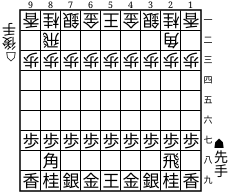

lnsgkgsnl/1r5b1/ppppppppp/9/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL w - 1 2113


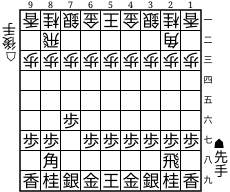

lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL w - 1 1984


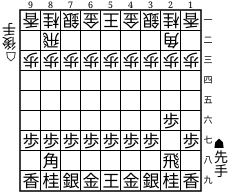

lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL b - 1 1572


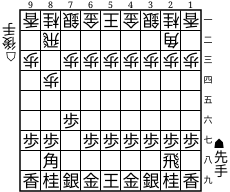

lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL b - 1 1472


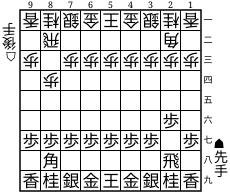

lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P4P1/PP1PPPP1P/1B5R1/LNSGKGSNL w - 1 1265


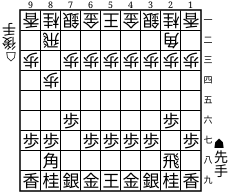

lnsgkgsnl/1r5b1/p1ppppppp/9/1p7/2P4P1/PP1PPPP1P/1B5R1/LNSGKGSNL b - 1 887


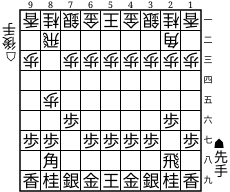

lnsgkgsnl/1r5b1/p1ppppppp/1p7/7P1/9/PPPPPPP1P/1B5R1/LNSGKGSNL w - 1 825


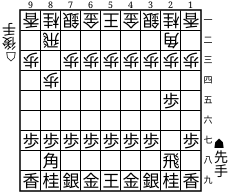

lnsgkgsnl/1r5b1/p1ppppppp/9/1p7/2P4P1/PPBPPPP1P/7R1/LNSGKGSNL w - 1 758


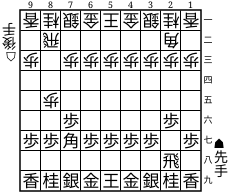

lnsgkgsnl/1r5b1/p1pppp1pp/6p2/1p7/2P4P1/PPBPPPP1P/7R1/LNSGKGSNL b - 1 702


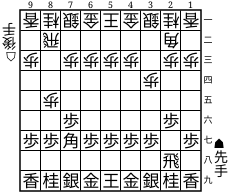

In [19]:
board = cshogi.Board()
for pos, count in pos_counts.head(10).items():
    print(pos, count)
    board.set_sfen(pos)
    display(board.to_svg())

## Think with the engine itself

In [20]:
import sys
sys.path.insert(1, '../utils')

In [21]:
from importlib import reload  
import usi_engine
reload(usi_engine)

<module 'usi_engine' from '../utils/usi_engine.py'>

In [22]:
import asyncio

engines = []

paths = [
    '/Users/hmats/workspace/DeepLearningShogi/x64/Release/dlshogi_tensorrt.exe',
#     '/Users/hmats/Downloads/YaneuraOu-v5.33-windows/windows/NNUE/YaneuraOu_NNUE-tournament-clang++-zen2.exe'
]

if sys.platform.startswith('linux'):
    paths = ['/mnt/c' + p for p in paths]

# path must be absolute
for path in (paths * 1):
    os.chdir(os.path.dirname(path))
    proc = await asyncio.create_subprocess_exec("./" + os.path.basename(path), stdout=asyncio.subprocess.PIPE, stdin=asyncio.subprocess.PIPE)
#     proc = await asyncio.create_subprocess_shell("./" + os.path.basename(path), stdout=asyncio.subprocess.PIPE, stdin=asyncio.subprocess.PIPE)
    engine = await usi_engine.USIEngine.create(proc)
    engines.append(engine)
    
    await engine.set_option('DNN_Model', 'model-test.232000.onnx')
    await engine.send('usi')
    await engine.wait_for('usiok')
    await engine.send('isready')
    await engine.wait_for('readyok')

In [23]:
await engine.send(f'position sfen ln1gkgsnl/1r1s3b1/p1pppp1pp/1p4p2/9/2P6/PPSPPPPPP/1B5R1/LN1GKGSNL b - 1')
await engine.send('go byoyomi 5000')
await engine.wait_for('bestmove')
print(engine.best_move)

bestmove 2g2f


In [24]:
os.getcwd()

'/mnt/c/Users/hmats/workspace/DeepLearningShogi/x64/Release'

In [ ]:
with open("bestmoves.csv", "w", buffering=1) as f:
    ipos = 0
    for pos, count in pos_counts.items():
        await engine.send(f'position sfen {pos}')
        await engine.send('go byoyomi 120000')
        await engine.wait_for('bestmove')
        
        bestmove = engine.best_move.split(' ', 1)[1]
        line = f"{ipos}, {count}, {pos}, {bestmove}"
        print(line, flush=True)
        f.write(line + '\n')
        f.flush()
        
        ipos += 1

0, 3709, lnsgkgsnl/1r5b1/ppppppppp/9/9/9/PPPPPPPPP/1B5R1/LNSGKGSNL b - 1, 2g2f
1, 2113, lnsgkgsnl/1r5b1/ppppppppp/9/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL w - 1, 8c8d
2, 1984, lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL w - 1, 8c8d
3, 1572, lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL b - 1, 2g2f
4, 1472, lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL b - 1, 7g7f
5, 1265, lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P4P1/PP1PPPP1P/1B5R1/LNSGKGSNL w - 1, 4a3b
6, 887, lnsgkgsnl/1r5b1/p1ppppppp/9/1p7/2P4P1/PP1PPPP1P/1B5R1/LNSGKGSNL b - 1, 2f2e
7, 825, lnsgkgsnl/1r5b1/p1ppppppp/1p7/7P1/9/PPPPPPP1P/1B5R1/LNSGKGSNL w - 1, 8d8e
8, 758, lnsgkgsnl/1r5b1/p1ppppppp/9/1p7/2P4P1/PPBPPPP1P/7R1/LNSGKGSNL w - 1, 3c3d
9, 702, lnsgkgsnl/1r5b1/p1pppp1pp/6p2/1p7/2P4P1/PPBPPPP1P/7R1/LNSGKGSNL b - 1, 7i8h
10, 698, lnsgkgsnl/1r5b1/pppppp1pp/6p2/9/2P4P1/PP1PPPP1P/1B5R1/LNSGKGSNL w - 1, 4c4d
11, 670, lnsgkgsnl/1r5b1/p1ppppppp/9/1p5P1/9/PPPPPPP1P/1B5R1/LNSGKGSNL b - 1, 7g7f
12, 599,

In [ ]:
with open("bestmoves.csv", "a", buffering=1) as f:
    ipos = 1008
    for pos, count in pos_counts.iloc[ipos:].items():
        await engine.send(f'position sfen {pos}')
        await engine.send('go byoyomi 120000')
        await engine.wait_for('bestmove')
        
        bestmove = engine.best_move.split(' ', 1)[1]
        line = f"{ipos}, {count}, {pos}, {bestmove}"
        print(line, flush=True)
        f.write(line + '\n')
        f.flush()

        ipos += 1

1008, 16, ln1gk1snl/2s3g2/p1pppp3/1r4pRp/9/P1P3P2/3PPP2P/1+bG1K1S2/LNS2G1NL b 2Pb2p 1, 7i8h
1009, 16, lnsgkgsnl/1r7/p1pppp1pp/1p4p2/9/2P6/PP+bPPPPPP/3S3R1/LN1GKGSNL b b 1, 6h7g
1010, 16, lnsgk1snl/1r4gb1/p1pppppp1/8p/1p5P1/P8/1PPPPPP1P/1BG4R1/LNS1KGSNL b - 1, 3i3h
1011, 16, l4r1nl/3g1kg2/2n1p1sp1/p1ppspp1p/1p5P1/P1PPSPP1P/1PS1P1N2/2G2G3/LNK4RL b Bb 1, 4f4e
1012, 15, lnsgkg1nl/1r4s2/1pppp1bpp/p4pp2/7P1/2P3P2/PP1PPP2P/1B1K3R1/LNSG1GSNL b - 1, 9g9f
1013, 15, lnsgkg1nl/1r5s1/1ppppp1pp/6p2/p6P1/2P6/PP1PPPP1P/1SK4R1/LN1G1GSNL w Bb 1, 2b3c
1014, 15, l4r1nl/3gk1g2/2n1p1sp1/p1ppspp1p/1p3P1P1/P1PPS1P1P/1PS1P1N2/2G2G3/LNK4RL b Bb 1, 4e4d
1015, 15, lr5nl/3g1kgs1/2n1pp1p1/p1pps2Pp/1p3Np2/P1PPSP2P/1PS1P4/1KG2G3/LN5RL w Bbp 1, 2c2d
1016, 15, lnsgk1snl/1r4gb1/pppppp1pp/6p2/8P/2P6/PP1PPPPP1/1B5R1/LNSGKGSNL w - 1, 7a6b
1017, 15, ln1gk2nl/1r4g2/p1p1ppspp/3ps1p2/1p5P1/2P2SP2/PPSPPP2P/3K3R1/LN1G1G1NL b Bb 1, 6h7i
1018, 15, ln1gk2nl/1r1s1sgb1/p1pppp1pp/1p4p2/9/2P4P1/PPSPPPP1P/1B3S1R1/LN1GKG1NL b - 1, 6i7h
1

In [ ]:
with open("bestmoves.csv", "a", buffering=1) as f:
    ipos = 1391
    for pos, count in pos_counts.iloc[ipos:].items():
        await engine.send(f'position sfen {pos}')
        await engine.send('go byoyomi 120000')
        await engine.wait_for('bestmove')
        
        bestmove = engine.best_move.split(' ', 1)[1]
        line = f"{ipos}, {count}, {pos}, {bestmove}"
        print(line, flush=True)
        f.write(line + '\n')
        f.flush()

        ipos += 1

1391, 12, ln1gk2nl/1r1s1sgb1/p1ppp2pp/5pp2/1p7/2P2P3/PPBPPSPPP/2GS3R1/LN2KG1NL b - 1, 5i6i
1392, 12, lnsgk1snl/1r4g2/p1pppp1pp/6p2/1p7/2P6/PPSPPPPPP/2G4R1/LN2KGSNL b Bb 1, 2g2f
1393, 12, lnsg2snl/1r3kg2/p1ppppppp/1P5R1/5N3/1pP3P2/P2PPP2P/1SG1K4/LN3GS1L b BPb 1, 2d2i
1394, 12, ln1g1g1nl/1r1s1k3/p2pppspp/2p3p2/1p6P/2PP5/PPS1PPPP1/2GR5/LN2KGSNL w Bb 1, 6a5b
1395, 12, lnsgk1snl/6g2/prppppb1p/6R2/9/1pP3P2/P2PPP2P/1BG1K4/LNS2GSNL b 2P2p 1, P*8d
1396, 12, lnsgkg1nl/7r1/1ppppsbpp/5pp2/p6P1/2P3P2/PP1PPPS1P/1BK1G2R1/LNSG3NL w - 1, 4a3b
1397, 12, ln1g1gsnl/1rs3k+B1/p1pppp1pp/6p2/1p6P/2P6/PP1PPPPP1/3R2K2/LNSG1GSNL w B 1, 3a2b
1398, 12, lr5nl/6gs1/2g1k2p1/p2pspp1p/1pp4P1/P2PSPP1P/1PS1P4/2G2G3/LNK4RL b BNbn2p 1, 2e2d
1399, 12, ln1gk1snl/1rs3gb1/p1pppppp1/8p/7P1/1P4P2/P1PPPP2P/1BG1K1SR1/LNS2G1NL w P 1, 8b8f
1400, 12, lnsgkgsnl/1r7/1pppp1bpp/p4pp2/7P1/2P6/PP1PPPP1P/1B1K3R1/LNSG1GSNL b - 1, 9g9f
1401, 12, ln1gk2nl/1r4gs1/3pp2p1/p1ps1pP1p/6SP1/PpP5P/2SPPP3/1PG1K2R1/LN3G1NL b Bbp 1, 6g6f
1402, 12, lr5nl/

In [ ]:
with open("bestmoves.csv", "a", buffering=1) as f:
    ipos = 1698
    for pos, count in pos_counts.iloc[ipos:].items():
        await engine.send(f'position sfen {pos}')
        await engine.send('go byoyomi 120000')
        await engine.wait_for('bestmove')
        
        bestmove = engine.best_move.split(' ', 1)[1]
        line = f"{ipos}, {count}, {pos}, {bestmove}"
        print(line, flush=True)
        f.write(line + '\n')
        f.flush()

        ipos += 1

1698, 11, ln1gk2nl/1r4g2/2psppspp/p2p2p2/1p5P1/P1P3P2/1PSPPP2P/2GK1S1R1/LN3G1NL b Bb 1, 4i5h
1699, 11, lnsg1g1nl/3k2r2/1ppppsbpp/p4pp2/7P1/P1P3P2/1P1PPPS1P/1B1K3R1/LNSG1G1NL b - 1, 4i5h
1700, 11, lnsgkgsnl/4r2b1/pppp1p1pp/6p2/4p2P1/2P6/PP1PPPP1P/1B1K3R1/LNSG1GSNL b - 1, 3i4h
1701, 11, lnsgk2nl/5rg2/1pppppspp/6p2/p6P1/2P3P2/PPSPPP2P/3KGS1R1/LN1G3NL w Bb 1, 4c4d
1702, 11, ln1gk1snl/2s3gb1/p1ppppppp/1r7/7P1/9/PPPPPPP1P/1BG1K1SR1/LNS2G1NL b p 1, 3g3f
1703, 11, ln1gk2nl/1r4g2/p1psppspp/3p2p2/1p5P1/P1P3P2/1PSPPP2P/2GK1S1R1/LN3G1NL w Bb 1, 9c9d
1704, 11, ln1gk2nl/1r4g2/p1psp1spp/3p1pp2/1p5P1/2P3P2/PPSPPPS1P/2GK3R1/LN3G1NL b Bb 1, 4i5h
1705, 11, lnsgkgsnl/1r5b1/1pppp2pp/p4pp2/9/2P3PP1/PP1PPP2P/1B3S1R1/LNSGKG1NL w - 1, 9d9e
1706, 11, ln1g3nl/1r3kg2/3sppspp/p1pp2p2/1p5P1/P1P2PP2/1PSPP1N1P/2GK2SR1/LN3G2L b Bb 1, 1g1f
1707, 11, ln1gk2nl/1r4g2/3pppspp/p1ps5/6SP1/1PP5P/P1SPPP3/2G4R1/LN2KG1NL w B2Pbp 1, P*8e
1708, 11, ln1gk1snl/1rs3gb1/p1ppppppp/9/7P1/1P7/P1PPPPP1P/1BG1K1SR1/LNS2G1NL w P 1, 8b8f
1709

CancelledError: 

### Make book from SFEN files (white & black)

In [ ]:
!pwd

In [ ]:
# Run benchmark test
# ! (cd ../exe && ./YaneuraOu-by-gcc bench , quit)

In [ ]:
# Denryu-sen
! (cd ../exe && ./YaneuraOu-by-gcc makebook from_sfen bw ../notebook/dr_black.sfen ../notebook/dr_white.sfen ../notebook/denryu.db moves 512 , quit)

In [ ]:
# ! sed 's/position //g' fl_black.sfen > fg_black.sfen

In [ ]:
# ! sed 's/position //g' fl_white.sfen > fg_white.sfen

In [ ]:
# Floodgate
! (cd ../exe && ./YaneuraOu-by-gcc makebook from_sfen bw ../notebook/fg_black.sfen ../notebook/fg_white.sfen ../notebook/floodgate.db moves 512 , quit)

## Merge book files

#### Prune Merged UCB Book

In [ ]:
! (cd ../exe && python3 prune_book.py --help)

In [ ]:
# ! (cd ../exe && python3 prune_book.py uct_book_merged.pruned1000 --help)

#### Merge UCB and Flood gate books

In [ ]:
# makebook merge yaneura_book1.db yaneura_book2.db yaneura_book3.db
! (cd ../exe && ./YaneuraOu-by-gcc makebook merge ../notebook/floodgate.db uct_book_merged.pruned1000 ../notebook/floodgate-uct.db , quit)

In [ ]:
! (cd ../notebook && ln -s floodgate.db user_book1.db)
! (cd ../notebook && ln -s floodgate-uct.db user_book2.db)

## Edit book with huristics

In [ ]:
huristics = {
    # 76
    "sfen lnsgkgsnl/1r5b1/ppppppppp/9/9/2P6/PP1PPPPPP/1B5R1/LNSGKGSNL w - 2": "8c8d",
    "sfen lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P6/PP1PPPPPP/1BG4R1/LNS1KGSNL w - 4": "8d8e",
    # 26
    "sfen lnsgkgsnl/1r5b1/ppppppppp/9/9/7P1/PPPPPPP1P/1B5R1/LNSGKGSNL w - 2": "8c8d",
    "sfen lnsgkgsnl/1r5b1/p1ppppppp/1p7/7P1/9/PPPPPPP1P/1B5R1/LNSGKGSNL w - 4": "8d8e",
    # 26 <-> 76
    "sfen lnsgkgsnl/1r5b1/p1ppppppp/1p7/9/2P4P1/PP1PPPP1P/1B5R1/LNSGKGSNL w - 4": "8d8e",
    "sfen lnsgk1snl/1r4gb1/p1ppppppp/9/1p5P1/2P6/PP1PPPP1P/1BG4R1/LNS1KGSNL w - 8": "8e8f",
    "sfen lnsgkgsnl/1r5b1/p1pppp1pp/6p2/1p5P1/2P6/PP1PPPP1P/1BG4R1/LNS1KGSNL w - 8": "4a3b",
}

In [ ]:
with open('floodgate-uct.db') as infile, open('floodgate-uct-edited.db', 'w') as outfile:
    line = infile.readline()
    while(line):
        if line.strip() in huristics.keys():
            outfile.write(line)
            
            move = huristics[line.strip()]
            for line in infile:
                if line.startswith('sfen '):
                    break
                if line.startswith(move) or line.startswith('#'):
                    outfile.write(line)
                else:
                    outfile.write('# ' + line)
        else:
            outfile.write(line)
            line = infile.readline()


## Make book from csa records in a directory

In [ ]:
indir = 'records_for_book'
outfile_name = 'makebook_think.sfen'
with open(outfile_name, 'w') as outfile:
    for filename in os.listdir(indir):
        if filename.endswith(".csa"):
            print(os.path.join(directory, filename))
            csa = open('very_Important.txt', 'r').read()
            sfen = get_sfen_from_csa(csa)
            print(sfen)
            outfile.write(sfen + '\n')
        else:
            continue